# Assignment 1

Note: This notebook file for the assignment has deviations from the course guide with respect to the structure, sentence framing, question framing and numbering. Please consider this notebook file structure as the final structure and follow this.

In this assignment, you will explore the CIFAR10 dataset. 

You have to download the dataset from Pytorch.

Comment your code and indicate what the different instructions are doing and what you are showing and printing. 
When printing figures do not forget about the title, x and y labels. The font size should be matching the text size of the text in your report. 
Do not forget to add legends to the plots. 

In [1]:
# Load all the needed packages for this assignment here
import matplotlib.pyplot as plt
import numpy as np

#### Exercise 1.1 - Load data

**a)** Load the CIFAR10 dataset. 

**b)** Print the number of samples and the number of classes present in the dataset. 

**c)** Also print the shape of an image in the dataset. 

In [2]:
# Ex.1.1a,b & c
import torchvision 
from torch.utils.data import ConcatDataset

data_path = './'

# Importing the dataset
dataset_train = torchvision.datasets.CIFAR10(data_path, train = True, download = True)
dataset_test = torchvision.datasets.CIFAR10(data_path, train = False , download = False)
combined_dataset = ConcatDataset([dataset_train, dataset_test])

# Printing the samples of the dataset
print('Total dataset size', len(combined_dataset))
print('The number of train samples', len(dataset_train))
print('The number of test samples', len(dataset_test))
print('The number of classes', len(dataset_test.classes))

# One image from the dataset
img, label = dataset_train[0]
print('The size of one image', img.size)


Files already downloaded and verified
Total dataset size 60000
The number of train samples 50000
The number of test samples 10000
The number of classes 10
The size of one image (32, 32)


#### Exercise 1.2 - Quantify dataset

**a)** Print the number of samples per category.

In [3]:
# Ex.1.2a 
classes = {cls: 0 for cls in dataset_train.classes}

for label in dataset_train.targets:
    class_name = dataset_train.classes[label]
    classes[class_name] += 1
print('Classes in the dataset', classes)


Classes in the dataset {'airplane': 5000, 'automobile': 5000, 'bird': 5000, 'cat': 5000, 'deer': 5000, 'dog': 5000, 'frog': 5000, 'horse': 5000, 'ship': 5000, 'truck': 5000}


**b)** Plot the number of samples per category using a bar plot.

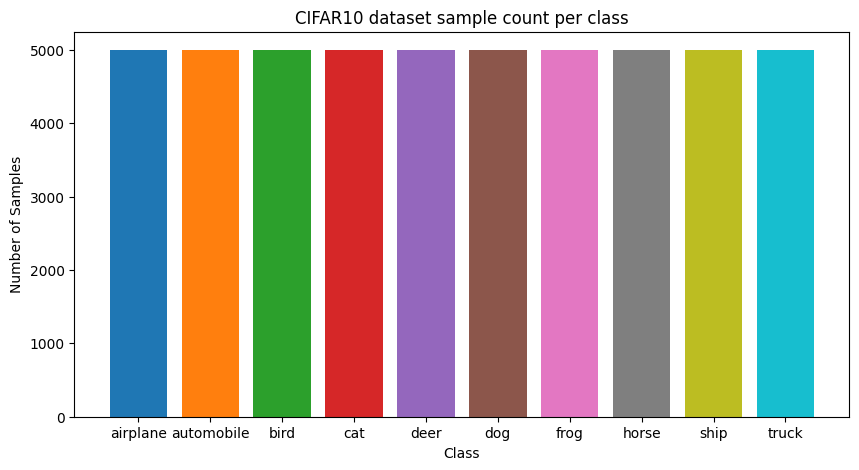

In [4]:
# Ex.1.2b your code here
from collections import Counter
from matplotlib import cm

counts = Counter(dataset_train.targets)
values = [counts[i] for i in range(len(dataset_train.classes))]

colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

plt.figure(figsize=(10,5))
plt.bar(dataset_train.classes, values, color=colors)
plt.title("CIFAR10 dataset sample count per class")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

**Reflection: Answer the below question**

Are you working with a balanced or an unbalanced dataset? Are there majoritarian classes? Do you think this will affect the later analysis and training of your models?

Answer: The dataset is balanced with equal number of samples per each class.

#### Exercise 1.3 - Visualize images in your dataset

Create a figure with n x 4 sub-plots. The value of 'n' depends on the number of categories present in the dataset.
As the title of each row in your figure, indicate the category it belongs to.

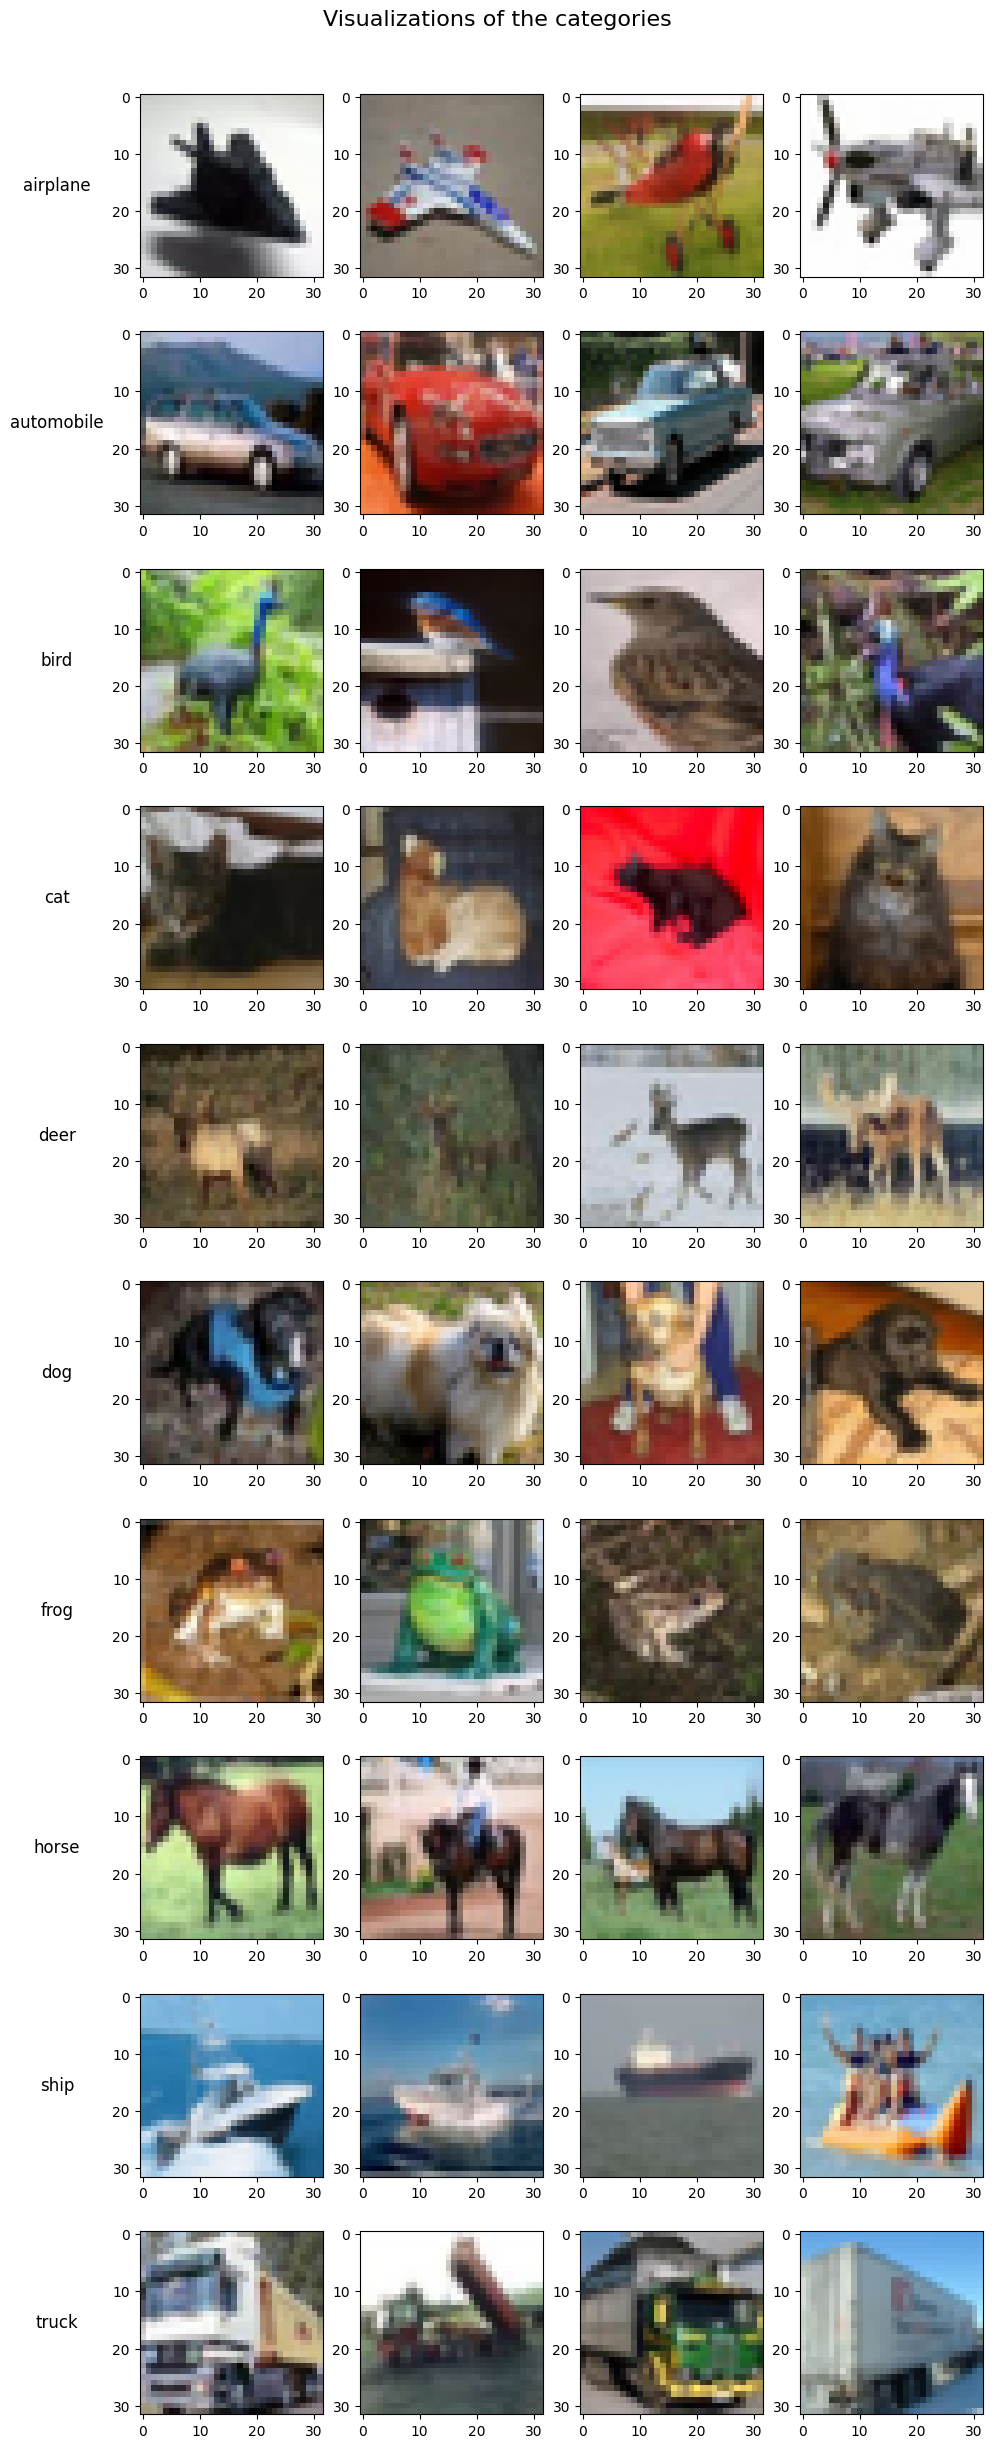

In [14]:
# Ex.1.3 
import torchvision
from torchvision import transforms

n_classes = len(classes)
images_per_class = 4

# collecting the images per each class
samples = { cls: [] for cls in range(n_classes)}

for img, label in dataset_train:
    if len(samples[label]) < images_per_class:
        samples[label].append(img)
    if all(len(samples[c]) == images_per_class for c in samples):
        break
        
# Visualization 
fig, axes = plt.subplots(nrows=n_classes, ncols= images_per_class, figsize=(10, 2.5*n_classes))
fig.suptitle('Visualizations of the categories', fontsize = 16)

for cls_idx, cls_name in enumerate(classes):
    for j in range(images_per_class):
        ax = axes[cls_idx, j]
        ax.imshow(samples[cls_idx][j])
    axes[cls_idx, 0].set_ylabel(cls_name, rotation=0, fontsize=12, labelpad=40, va='center')
       
plt.tight_layout(rect = [0,0,1,0.97])
plt.show()

#### Exercise 1.4 - RGB feature extraction

Extract RGB values from each image in your dataset as three seperate lists(one per channel). Each list should have 8 values. To do so, you can compute the histogram of each channel with 8 bins. Then you have to concatenate the values of all the three channels together resulting in a feature vector of size 24. This feature vector is the descriptor of an image in your dataset. You will have to do this for all the images present in your dataset in order to get the overall RGB descriptor which will be of size (n,24). Here 'n' depends on the number of samples present in the dataset. 

In [17]:
def rgb_descriptor(data):
    
    img = np.array(data)   # shape: (32, 32, 3)

    # per-channel histograms
    r_hist, _ = np.histogram(img[:, :, 0], bins=8, range=(0, 255))
    g_hist, _ = np.histogram(img[:, :, 1], bins=8, range=(0, 255))
    b_hist, _ = np.histogram(img[:, :, 2], bins=8, range=(0, 255))

    # normalize to sum=1 
    r_hist = r_hist / img[:, :, 0].size
    g_hist = g_hist / img[:, :, 1].size
    b_hist = b_hist / img[:, :, 2].size

    # concatenate to 24-D feature
    return np.concatenate([r_hist, g_hist, b_hist])  # shape = (24,)

rgb_descriptors = []
rgb_labels = []

for img, label in combined_dataset:
    rgb_descriptors.append(rgb_descriptor(img))
    rgb_labels.append(label)

rgb_descriptors = np.array(rgb_descriptors)   # shape: (n, 24)
rgb_labels = np.array(rgb_labels)

print(rgb_descriptors.shape)   # (50000, 24)


(60000, 24)


#### Exercise 1.5 - Compute the inter-class variability of your dataset.

Inter-class correlation aims at understanding the relationship/correlation among the classes/categories present in your dataset. For this, you could compute a measure (for example mean, std etc.) collectively for all the samples belonging to each and every class of the dataset. Then you could make use of this measure to find the correlation among the classes/categories using the standard pandas dataframe correlation function. Link: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

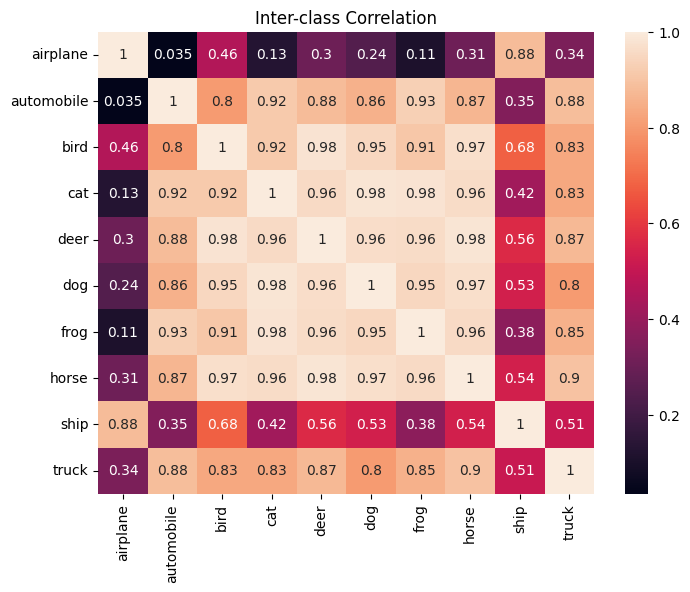

In [16]:
import pandas as pd
import seaborn as sns

# extracting labels from the datasets
labels = np.array([label for _, label in combined_dataset])

class_means = []
for cls_idx in range(len(classes)):
    cls_features = features[labels == cls_idx]
    mean_vec = cls_features.mean(axis = 0)
    class_means.append(mean_vec)

# converting to pandas dataframe
df = pd.DataFrame(class_means, index=classes)

corr_matrix = df.T.corr(method='pearson')

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True)
plt.title('Inter-class Correlation')
plt.show()


**c)** Compute the Silhouette score. 

The Silhouette score is used to assess the performance of using unsupervised machine learning (clustering). We can also use it here to assess the compactness of the extracted descriptors per category and for the group of categories as their mean.

You can use the function available in Sklearn - https://scikitlearn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

In [26]:
from sklearn.metrics import silhouette_score

overall_sil = silhouette_score(rgb_descriptors, rgb_labels)
print("The overal silhouette score for the dataset:", overall_sil)

sil_scores_per_class = {}

for cls_idx, cls_name in enumerate(classes):
    
    # Extract samples of this class and all the others
    X_cls = rgb_descriptors[rgb_labels == cls_idx]
    X_other = rgb_descriptors[rgb_labels != cls_idx]
    X_combined = np.vstack([X_cls, X_other])

    # Make labels: 1 for this class, 0 for all others
    y_combined = np.hstack([np.ones(len(X_cls)), np.zeros(len(X_other))])

    # Silhouette score for this class
    score = silhouette_score(X_combined, y_combined)
    sil_scores_per_class[cls_name] = score

# Print results
print("Silhouette score per class:")
for cls, score in sil_scores_per_class.items():
    print(f"{cls:10s}: {score:.4f}")



The overal silhouette score for the dataset: -0.08464909909009971
Silhouette score per class:
airplane  : 0.1683
automobile: -0.0808
bird      : 0.1087
cat       : -0.0301
deer      : 0.0362
dog       : -0.0455
frog      : 0.0083
horse     : -0.0627
ship      : 0.0179
truck     : -0.0968


**Reflection: (Answer the below questions)** 

**1.** Does Intra-class correlation score/coefficient help you assess the degree of similarity among the samples of a category?

Yes. It measures how similar the samples within a class are. High values mean the class is compact and consistent; low values mean the samples are diverse.

**2.** What can you deduce from the Inter-class correlation and Silhouette score?

Both show that CIFAR-10 classes are not well separated using RGB histograms.
Inter-class correlations are high, and many silhouette scores are negative, meaning several classes overlap heavily in color space.

#### Exercise 1.6 - Dimensionality reduction for visualization 

We can visualize large datasets having higher dimensions or features in 2- or 3-dimensional spaces. For this, you need to reduce the dimensionality of the data. 

In this exercise, you are asked to use PCA for reducing dimensionality.

Link to function to apply PCA: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

Create the following two figures:

**a)** Rely on the first 2 principal components to plot the samples of your dataset. Use one color per class.

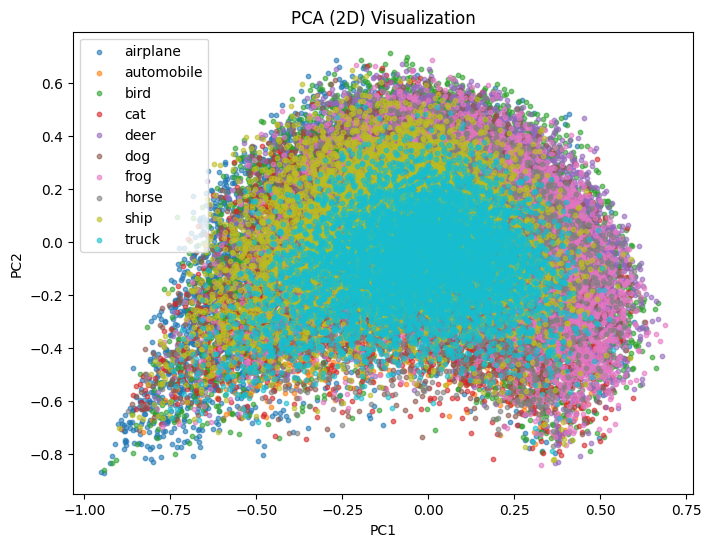

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
features_2d = pca.fit_transform(rgb_descriptors)

plt.figure(figsize=(8,6))

for cls_idx, cls_name in enumerate(classes):
    cls_points = features_2d[labels == cls_idx]
    plt.scatter(cls_points[:, 0], cls_points[:,1], color=colors[cls_idx], s=10, alpha=0.6, label=cls_name)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2D) Visualization")
plt.legend()
plt.show()
    

**b)** Rely on the first 3 principal components to create a 3D plot. Use one color per class.

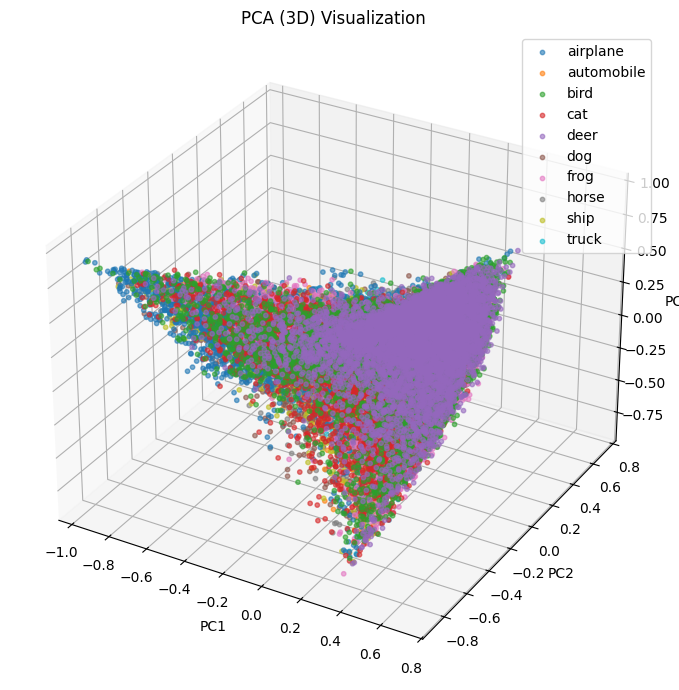

In [29]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D


pca = PCA(n_components=3)
features_3d = pca.fit_transform(rgb_descriptors)  
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

for cls_idx, cls_name in enumerate(classes):
    cls_points = features_3d[labels == cls_idx]
    ax.scatter(cls_points[:, 0], cls_points[:, 1], cls_points[:, 2], color=colors[cls_idx], s=10, alpha=0.6, label=cls_name)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA (3D) Visualization")
ax.legend()
plt.tight_layout()
plt.show()


#### Exercise 1.7 - Reflection

Reflect on the following questions.

**a)** Will you obtain the same visualisation in the feature space for different extracted features? 

No. Different feature extractors (e.g., RGB histograms, CNN embeddings) encode different types of information. The resulting feature distributions and their PCA projections will differ because PCA reflects the variance structure of whatever descriptor you provide. 
    
**b)** Are the classes distinguishable on the feature space when relying on PCA over RGB?

RGB histograms are low-level features and capture color distribution, not shape or semantics. As a result, many CIFAR-10 classes overlap heavily in PCA space, and only color-biased categories 
    
**c)** What other visualization could you include to better describe your data?

t-SNE or UMAP plots, which preserve local neighborhood structure more effectively than PCA. Additionally, class-wise histograms, cluster dendrograms, pairwise distance matrices, or visualization after extracting deep CNN features 

#### [Optional] Exercise: Repeat experiments with different image descriptors

e.g. 
- Harris Corner Detection

- Shi-Tomasi Corner Detector and Good Features to Track

- Scale-Invariant Feature Transform (SIFT)

- Speeded-up robust features (SURF)

- Features from Accelerated Segment Test (FAST)

- Blob Detectors With LoG, DoG, and DoH

If you have OpenCV installed you can follow this example,
https://automaticaddison.com/image-feature-detection-description-and-matching-in-opencv/

When using Scikit-image,
https://scikit-image.org/docs/dev/api/skimage.feature.html?highlight=hog